## NLP Final
### Part 2: Topic Detection - LDA (Title)
### Aren Mizuno
### March 12, 2026

In [1]:
# Imports
!pip -q install gensim pyLDAvis

import re
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import warnings
warnings.filterwarnings("ignore")
from gensim.corpora import Dictionary
from gensim.models import LdaModel, LdaMulticore
from gensim.models.phrases import Phrases, Phraser
from gensim.models.coherencemodel import CoherenceModel
from google.colab import drive, files
import nltk
from nltk.corpus import stopwords

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 108.9 MB/s eta 0:00:00


In [2]:
# Cuda
torch.cuda.is_available()

True

In [3]:
# Mount drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
# Load the cleaned dataset
data_path = "/content/drive/MyDrive/UChicago/Masters/Winter/NLP/Final Project/parquets/news_final_project_cleaned.parquet"
df = pd.read_parquet(data_path, engine="pyarrow")
df.head(2)

,url,date,title,text
0,https://blockworks.co/price/bad,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod..."
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,This AI video of gymnastics might be the freak...,This AI video of gymnastics might be the freak...


In [5]:
# Check shape
df.shape

(136233, 4)

In [6]:
# Clean data
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

# Extra junk words common in news titles
TITLE_JUNK_WORDS = {
    "menu","search","login","subscribe","newsletter","privacy","policy",
    "terms","service","contact","support","home","world","business",
    "finance","sports","weather","entertainment","store","blog",
    "forums","shop","mail","read","more","follow","video","watch",
    "breaking","update"
}

def clean_text(s):
    s = str(s).lower()

    # Remove URLs
    s = re.sub(r"http\S+|www\.\S+", " ", s)

    # Remove timestamps like 12:34 PM or 23:08:29 PKT
    s = re.sub(r"\b\d{1,2}:\d{2}(:\d{2})?\s*(am|pm|[A-Z]{2,5})?\b", " ", s)

    # Remove dates
    s = re.sub(r"\b\d{4}-\d{2}-\d{2}\b", " ", s)
    s = re.sub(r"\b\d{1,2}/\d{1,2}/\d{2,4}\b", " ", s)

    # Remove ticker fragments
    s = re.sub(r"\$[a-z]{1,6}\b", " ", s)
    s = re.sub(r"\[[A-Z0-9.\-]{1,10}\]", " ", s)

    # Remove separators
    s = re.sub(r"[_|•\-–—/]+", " ", s)

    # Remove non-letter text
    s = re.sub(r"[^a-z\s]", " ", s)

    # Normalize spaces
    s = re.sub(r"\s+", " ", s).strip()

    words = s.split()

    # Remove stopwords + junk words
    words = [
        w for w in words
        if w not in stop_words
        and w not in TITLE_JUNK_WORDS
        and len(w) > 2
    ]

    return " ".join(words)

df["title"] = df["title"].map(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
# Tokenize
normalized_corpus = df["title"].apply(lambda x: x.split()).tolist()
normalized_corpus[1][:30]

['gymnastics', 'might', 'freakiest', 'seen', 'yet', 'boing', 'boing']

In [8]:
# Train phrases model to detect bigrams
bigram_phraser = Phrases(
    normalized_corpus,
    min_count=20,     # helps control junk bigrams
    threshold=10.0    # higher = fewer phrases
)
bigram_mod = Phraser(bigram_phraser)

# Add bigrams to original documents (same spirit as your loop)
for i in range(len(normalized_corpus)):
    for tok in bigram_mod[normalized_corpus[i]]:
        if "_" in tok:
            normalized_corpus[i].append(tok)

In [9]:
# Make dictionary
dictionary = Dictionary(normalized_corpus)

dictionary.filter_extremes(
    no_below=int(0.01 * len(normalized_corpus)),  # appear in at least 1% of docs
    no_above=0.5                                  # appear in at most 50% of docs
)

corpus = [dictionary.doc2bow(doc) for doc in normalized_corpus]

print("Number of unique tokens:", len(dictionary))
print("Number of documents:", len(corpus))

Number of unique tokens: 91
Number of documents: 136233


In [10]:
# Get coherence score per # of topics
min_topics = 2
max_topics = 26
step_size = 2
topics_range = range(min_topics, max_topics + 1, step_size)

chunksize = 4000
iterations = 20
eval_every = 0
passes = 2
RANDOM_STATE = 0

coherence_scores = []

for num_topics in topics_range:
    model = LdaMulticore(
        corpus=corpus,
        id2word=dictionary,
        chunksize=chunksize,
        alpha="symmetric",
        eta="auto",
        iterations=iterations,
        num_topics=num_topics,
        passes=passes,
        eval_every=eval_every,
        workers=1,
        random_state=RANDOM_STATE
    )

    cm = CoherenceModel(
        model=model,
        texts=normalized_corpus,
        dictionary=dictionary,
        coherence="c_v"
    )
    coherence_scores.append(cm.get_coherence())

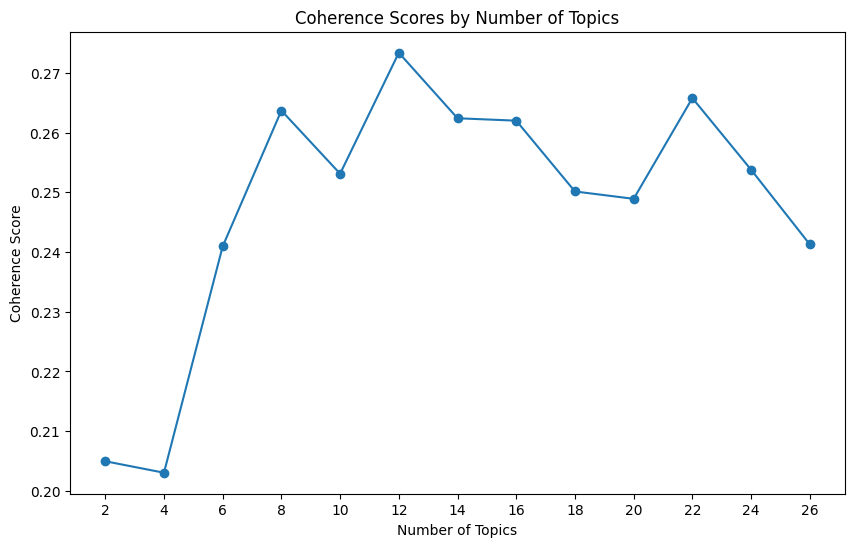

In [11]:
# Plot coherence score vs topics
plt.figure(figsize=(10, 6))
plt.plot(list(topics_range), coherence_scores, marker="o")
plt.title("Coherence Scores by Number of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.xticks(list(topics_range))
plt.show()

The coherence scores were evaluated across different numbers of topics. The highest coherence occurs at k = 12, after which coherence improvements plateau. Therefore, k = 12 was selected as the optimal number of topics.

In [12]:
# Train final LDA
chunksize = 4000
iterations = 20
eval_every = 0
passes = 2
RANDOM_STATE = 0


final_lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    chunksize=chunksize,
    alpha="auto",
    eta="auto",
    iterations=iterations,
    num_topics=12,
    passes=passes,
    eval_every=eval_every,
    random_state=RANDOM_STATE
)

In [13]:
# Assign topic distributions to each doc
document_topics = [final_lda_model.get_document_topics(doc) for doc in corpus]
df["lda_topics"] = document_topics

with pd.option_context("display.max_colwidth", 200):
    display(df[["title", "lda_topics"]].head(20))

,title,lda_topics
0,bad idea price bad market cap price today chart history blockworks,"[(0, 0.022334043), (1, 0.027211558), (2, 0.025691828), (3, 0.019373767), (4, 0.019084027), (5, 0.017077554), (6, 0.77037334), (7, 0.023704018), (8, 0.021632038), (9, 0.018654399), (10, 0.016658677..."
1,gymnastics might freakiest seen yet boing boing,"[(0, 0.089949496), (1, 0.1095935), (2, 0.10334718), (3, 0.07802711), (4, 0.07685935), (5, 0.06876824), (6, 0.075325444), (7, 0.09546702), (8, 0.0871222), (9, 0.07512987), (10, 0.06709218), (11, 0...."
2,using feels like chore try boing boing,"[(0, 0.051198795), (1, 0.062380064), (2, 0.058824692), (3, 0.04441263), (4, 0.043747954), (5, 0.03914253), (6, 0.04287486), (7, 0.054339346), (8, 0.049589515), (9, 0.47356853), (10, 0.03818853), (..."
3,road ahead china foundation model shaping future autonomous driving technology,"[(0, 0.022334019), (1, 0.027211528), (2, 0.025660599), (3, 0.5831531), (4, 0.0190838), (5, 0.017074816), (6, 0.01870294), (7, 0.023703992), (8, 0.021632014), (9, 0.018654378), (10, 0.01665866), (1..."
4,microsoft nvidia empower developers windows studio,"[(0, 0.035810996), (1, 0.043597925), (2, 0.34217775), (3, 0.031040344), (4, 0.030575795), (5, 0.027357029), (6, 0.33105814), (7, 0.037978202), (8, 0.034658507), (9, 0.02988778), (10, 0.026690269),..."
5,google releases new chatbot bard strong competitor openai chatgpt,"[(0, 0.17699417), (1, 0.022906758), (2, 0.179798), (3, 0.016308887), (4, 0.016064808), (5, 0.17256998), (6, 0.015744198), (7, 0.17815109), (8, 0.018209904), (9, 0.01570332), (10, 0.17222407), (11,..."
6,zoom expands offering companion revenue accelerator,"[(0, 0.089949496), (1, 0.1095935), (2, 0.10334718), (3, 0.07802711), (4, 0.07685935), (5, 0.06876824), (6, 0.075325444), (7, 0.09546702), (8, 0.0871222), (9, 0.07512987), (10, 0.06709218), (11, 0...."
7,pro thinking enhancing industrial environments artificial intelligence,"[(0, 0.027502406), (1, 0.033508636), (2, 0.031598803), (3, 0.023857089), (4, 0.7177461), (5, 0.021026155), (6, 0.023031047), (7, 0.029189412), (8, 0.02663795), (9, 0.022971248), (10, 0.020513695),..."
8,best prompts risk management,"[(0, 0.089949496), (1, 0.1095935), (2, 0.10334718), (3, 0.07802711), (4, 0.07685935), (5, 0.06876824), (6, 0.075325444), (7, 0.09546702), (8, 0.0871222), (9, 0.07512987), (10, 0.06709218), (11, 0...."
9,state ags warn companies clean child safeguards crooks liars,"[(0, 0.089949496), (1, 0.1095935), (2, 0.10334718), (3, 0.07802711), (4, 0.07685935), (5, 0.06876824), (6, 0.075325444), (7, 0.09546702), (8, 0.0871222), (9, 0.07512987), (10, 0.06709218), (11, 0...."


In [14]:
# Save dataframe with topic assignments
save_path_df = "/content/drive/MyDrive/UChicago/Masters/Winter/NLP/Final Project/parquets/lda_title.parquet"
df.to_parquet(save_path_df, engine="pyarrow", index=False)
print("Saved dataframe with topics to:", save_path_df)

Saved dataframe with topics to: /content/drive/MyDrive/UChicago/Masters/Winter/NLP/Final Project/parquets/lda_title.parquet


In [15]:
# Visualize
VIS_N = 20_000  # adjust down if needed (5k–20k)
vis_data = gensimvis.prepare(final_lda_model, corpus[:VIS_N], dictionary)
pyLDAvis.display(vis_data)

In [16]:
# Save HTML
save_path = "/content/drive/MyDrive/UChicago/Masters/Winter/NLP/Final Project/lda_vis_title.html"
pyLDAvis.save_html(vis_data, save_path)
print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/UChicago/Masters/Winter/NLP/Final Project/lda_vis_title.html
